# COVID-19 UK Data Analysis
*Author:* Sharon Trillo Nchana 
*Date:* 16/09/2025

## 1. Introduction
- Brief overview of the project.
- What dataset you are using (Our World in Data COVID-19 dataset).
- Main research questions:
  1. How did COVID-19 cases and deaths evolve over time in the UK?
  2. How did the vaccination rollout progress and impact the epidemic?
  3. How severe were the waves relative to population size?

## 2. Data Cleaning
- Brief description of steps applied to clean data:
  - Filled missing values with 0 where appropriate.
  - Forward-filled vaccinations to smooth data for visualisation.
  - Selected relevant columns for analysis.
- Display a small snippet of cleaned data using `df.head()`.


- Data cleaning script found in /scripts folder as 'load_and_clean.py'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid") # Makes it clean
plt.rcParams["figure.figsize"] = (12,6) # Sets the default figure size
# Load cleaned CSV
uk_df = pd.read_csv("../data/clean/uk_covid_clean.csv", parse_dates=["date"])
uk_df.head()

,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,new_vaccinations,people_vaccinated,people_fully_vaccinated,population
0,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68179267.0
1,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68179267.0
2,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68179267.0
3,2020-01-04,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,68179267.0
4,2020-01-05,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,68179267.0


The above shows 0 values as the pandemic had not yet begun in the UK

Below is the comfirmation of data handling

In [4]:
uk_df.isna().sum()


date                          0
total_cases                  21
new_cases                    21
total_deaths                 21
new_deaths                   21
total_vaccinations         1479
new_vaccinations           1481
people_vaccinated          1479
people_fully_vaccinated    1479
population                    0
dtype: int64

# 3. Results

## 3.1 - Epidemic Trends in the UK

New cases show multiple waves, with major peaks in 2020 (initial outbreak), winter 2021 (Alpha variant), and late 2021/early 2022 (Omicron).

New deaths follow a similar trend but decline in severity after 2021.

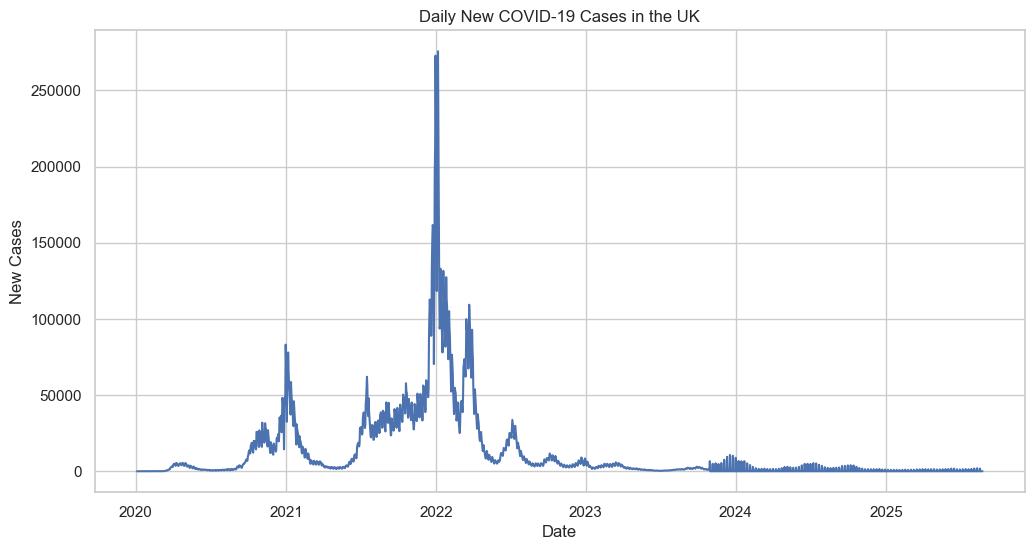

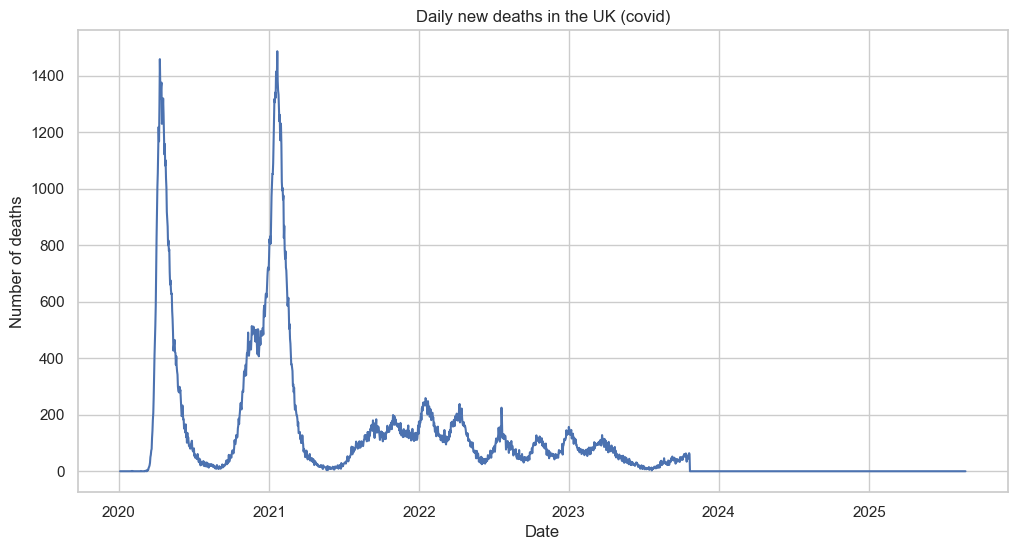

In [5]:


# Creates a graph to show the daily new cases
plt.figure()
sns.lineplot(data=uk_df, x="date", y="new_cases")
plt.title("Daily New COVID-19 Cases in the UK")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

# Daily new deaths in the UK
plt.figure()
sns.lineplot(data = uk_df, x= "date", y="new_deaths")
plt.title("Daily new deaths in the UK (covid)")
plt.xlabel("Date")
plt.ylabel("Number of deaths")
plt.show()

Key observations:

Peaks in cases: 2021 at the start and middle. Then hit the highest peak in 2022 and a following peak in the earlier months of 2022. Between this time cases were mainly above 50,00 cases

Peaks in deaths: Hit its fist peak in the earlier month of 2021, surpassing 1400 deaths, which gradually but drasticall deceased as the year went on. The it peaked past 1400 daily deaths again at the very start of 2021, following as similar pattern the the peak seen in 2020

Early waves of cases had higher death-to-case ratios.

## 3.2 - Vaccination Progress

### Graph 3: People Vaccinated vs Fully Vaccinated

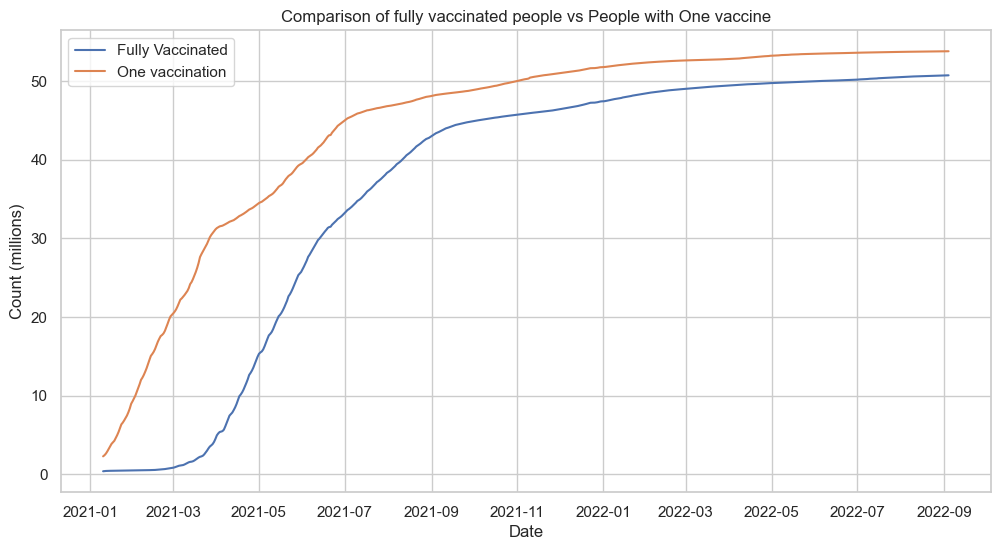

In [6]:
plt.figure()
sns.lineplot(data= uk_df, x= "date", y = uk_df["people_fully_vaccinated"]/1000000, label = "Fully Vaccinated")
sns.lineplot(data= uk_df, x= "date", y = uk_df["people_vaccinated"]/1000000, label = "One vaccination")
plt.title("Comparison of fully vaccinated people vs People with One vaccine")
plt.xlabel("Date")
plt.ylabel("Count (millions)")
plt.legend()
plt.show()

Key observations:

- Rapid rollout from Dec 2020 – mid 2021.

- Majority vaccinated by thend last few months of 2022 and OWID stopped reording vainations around that time, on 04/09/2022 

- Steady inrease from early 2021 to 2022



## 3.3 - Cases per Population 

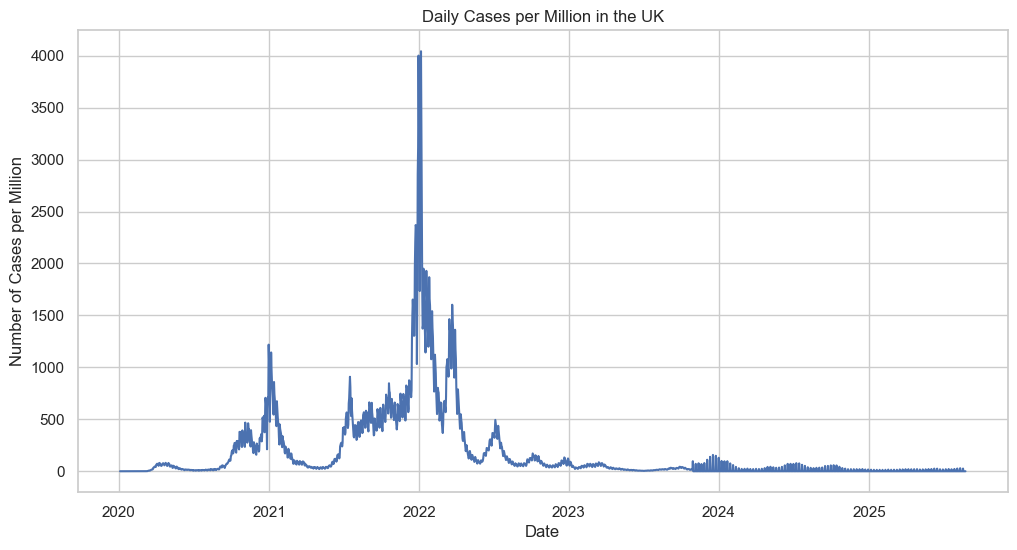

In [7]:
uk_df["cases_per_million"] = uk_df["new_cases"] / uk_df["population"] * 1_000_000

sns.lineplot(data=uk_df, x="date", y="cases_per_million")
plt.title("Daily Cases per Million in the UK")
plt.xlabel("Date")
plt.ylabel("Number of Cases per Million")
plt.show()


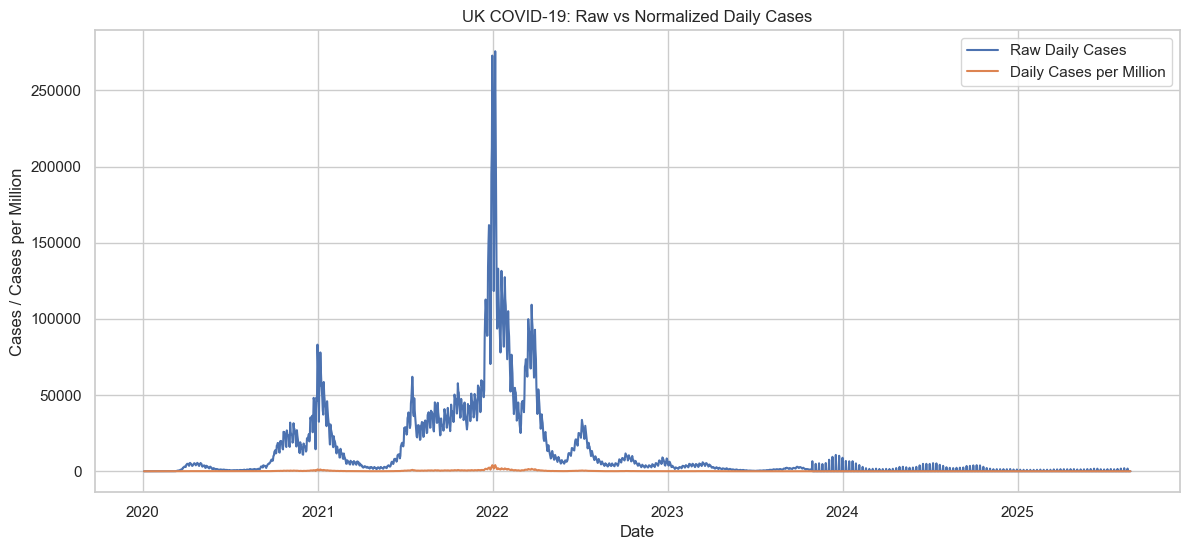

In [ ]:
 
# Make sure data is sorted by date
uk_df = uk_df.sort_values("date")

# Create normalised column
uk_df["cases_per_million"] = uk_df["new_cases"] / uk_df["population"] * 1_000_000

plt.figure(figsize=(14,6))

# Plot raw daily cases
sns.lineplot(data=uk_df, x="date", y="new_cases", label="Raw Daily Cases")

# Plot normalised daily cases
sns.lineplot(data=uk_df, x="date", y="cases_per_million", label="Daily Cases per Million")

plt.title("UK COVID-19: Raw vs Normalised Daily Cases")
plt.xlabel("Date")
plt.ylabel("Cases / Cases per Million")
plt.legend()
plt.show()


Key observations:

- Use of normalisation shows the amount of cases relative to the population in the UK. Therefore, Though the blue line looks like the cases are extreme in its raw form, when compared to the normalised value, we can see that it's not as extreme.

## 3.3 - Combined Subplots

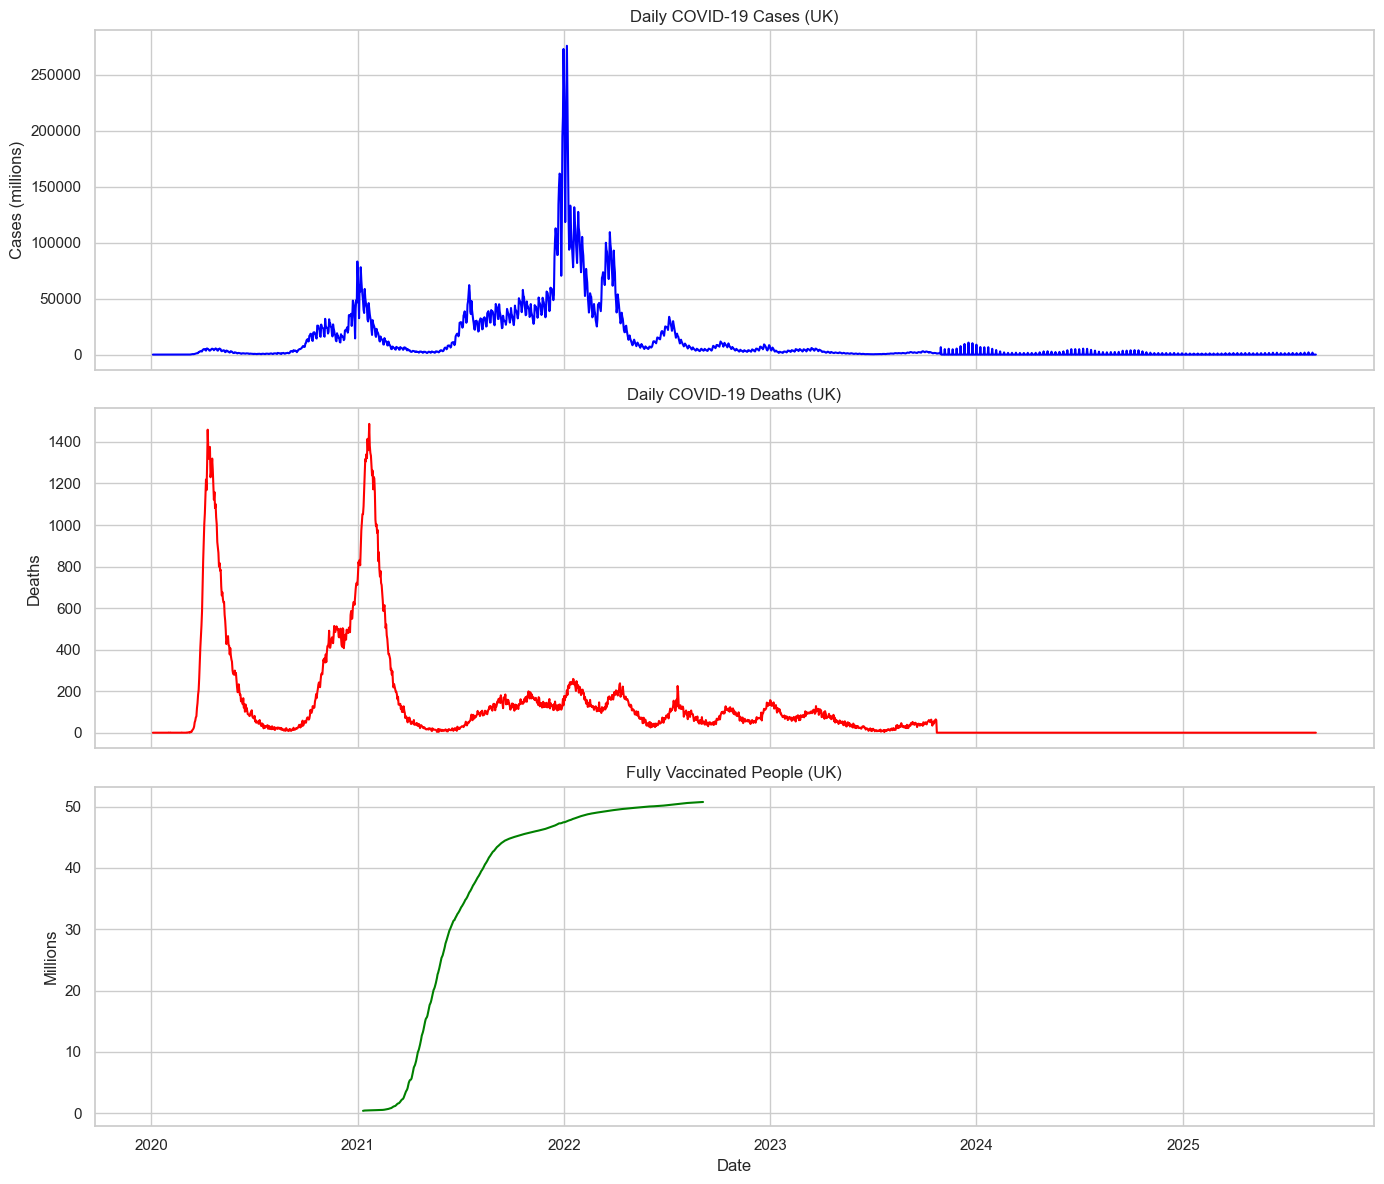

In [9]:
# Create a figure with 3 rows and 1 column of subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Daily cases
sns.lineplot(data=uk_df, x="date", y="new_cases", ax=axes[0], color="blue")
axes[0].set_title("Daily COVID-19 Cases (UK)")
axes[0].set_ylabel("Cases (millions)")

# 2. Daily deaths
sns.lineplot(data=uk_df, x="date", y="new_deaths", ax=axes[1], color="red")
axes[1].set_title("Daily COVID-19 Deaths (UK)")
axes[1].set_ylabel("Deaths")

# 3. Vaccinations
sns.lineplot(data=uk_df, x="date", y=uk_df["people_fully_vaccinated"]/1_000_000, ax=axes[2], color="green")
axes[2].set_title("Fully Vaccinated People (UK)")
axes[2].set_ylabel("Millions")
axes[2].set_xlabel("Date")

# Make sure titles and labels don’t overlap
plt.tight_layout()
plt.show()


Key Observations:

1. Daily Cases vs Daily Deaths

- Peaks in daily cases often precede peaks in daily deaths by a few weeks.

- Early waves had a higher death-to-case ratio compared to later waves.

- After vaccination rollout, daily deaths rise more slowly than cases.

2. Vaccination Progress

-Rapid increase in fully vaccinated population from late 2020 to mid-2021.

- As vaccination coverage increases, the gap between cases and deaths widens.


Overall:
- Vaccine data comes to a halt as OWID had stopped recording as the concerns regarding covid being a serious virus slowly decreased as we had vaccines now in place to counter and as most vulnerable people were now vaccinated.

- The combined plot clearly shows decoupling of cases and deaths after the vaccination campaign.

- Vaccination rollout appears correlated with reduced severity in death trends, despite ongoing case fluctuations.

## 4 - Discussion / Interpretation

1. Epidemic Dynamics

- Multiple waves of COVID-19 can be seen in both cases and deaths.

- Peaks in cases often precede peaks in deaths, consistent with disease progression.

- Early waves had a higher death-to-case ratio, reflecting lack of treatments and vaccines.

2. Effectiveness of Vaccines

- Vaccination rollout coincides with a decoupling of cases and deaths.

- Even during subsequent waves, deaths rise less sharply than cases once a large portion of the population is fully vaccinated.

3. Relative Burden Across Waves

- Normalised metrics (cases per million, deaths per million) show the relative severity of each wave.

- Later waves may have higher case counts but lower death rates, highlighting reduced severity.

4. Limitations 

- Missing or delayed reporting can cause false dips or spikes.

- Data does not distinguish between variants (Delta, Omicron, etc.).

- Only UK-specific — cannot generalise globally.

## 5 - Conclusion

- COVID-19 in the UK exhibited multiple waves with varying severity.

- Vaccination rollout had a clear impact in reducing deaths relative to cases.

- Normalised metrics like “cases per million” and “deaths per million” provide clearer comparisons over time.

- Data-driven understanding of these trends can inform future epidemic planning and public health policy.